In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [31]:
df = pd.read_csv('/content/drive/MyDrive/train.csv')

In [32]:
df = df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']]

In [33]:
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

Shape: (1460, 4)

Missing Values:
GrLivArea       0
BedroomAbvGr    0
FullBath        0
SalePrice       0
dtype: int64

Summary Statistics:


,GrLivArea,BedroomAbvGr,FullBath,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,1515.463699,2.866438,1.565068,180921.195890
std,525.480383,0.815778,0.550916,79442.502883
min,334.000000,0.000000,0.000000,34900.000000
25%,1129.500000,2.000000,1.000000,129975.000000
50%,1464.000000,3.000000,2.000000,163000.000000
75%,1776.750000,3.000000,2.000000,214000.000000
max,5642.000000,8.000000,3.000000,755000.000000


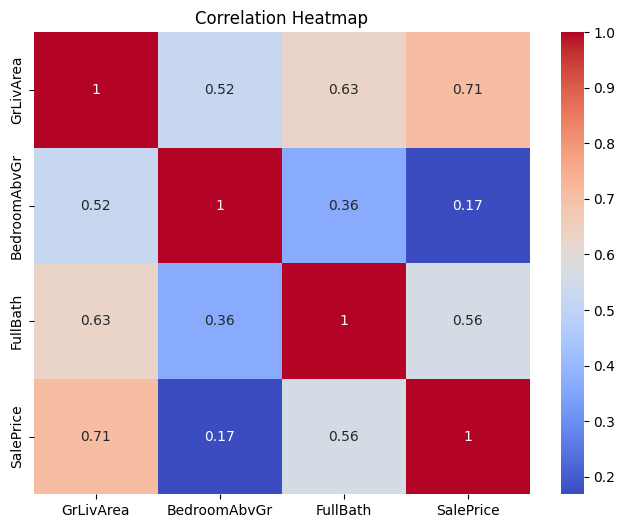

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

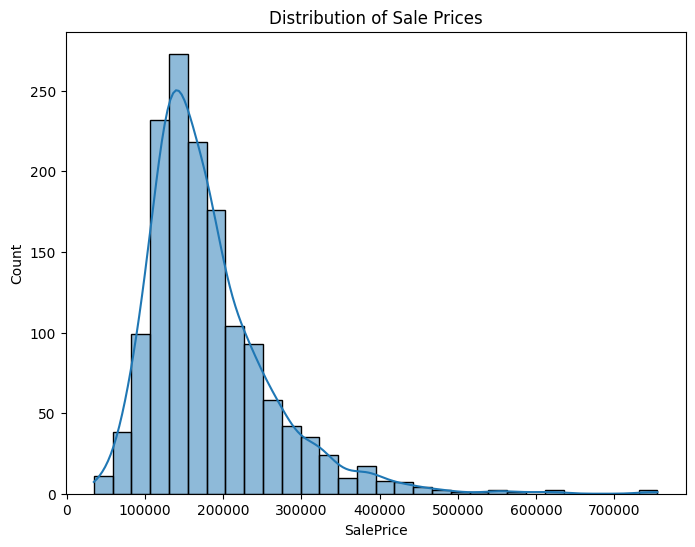

In [35]:
plt.figure(figsize=(8,6))
sns.histplot(df['SalePrice'], bins=30, kde=True)
plt.title("Distribution of Sale Prices")
plt.show()

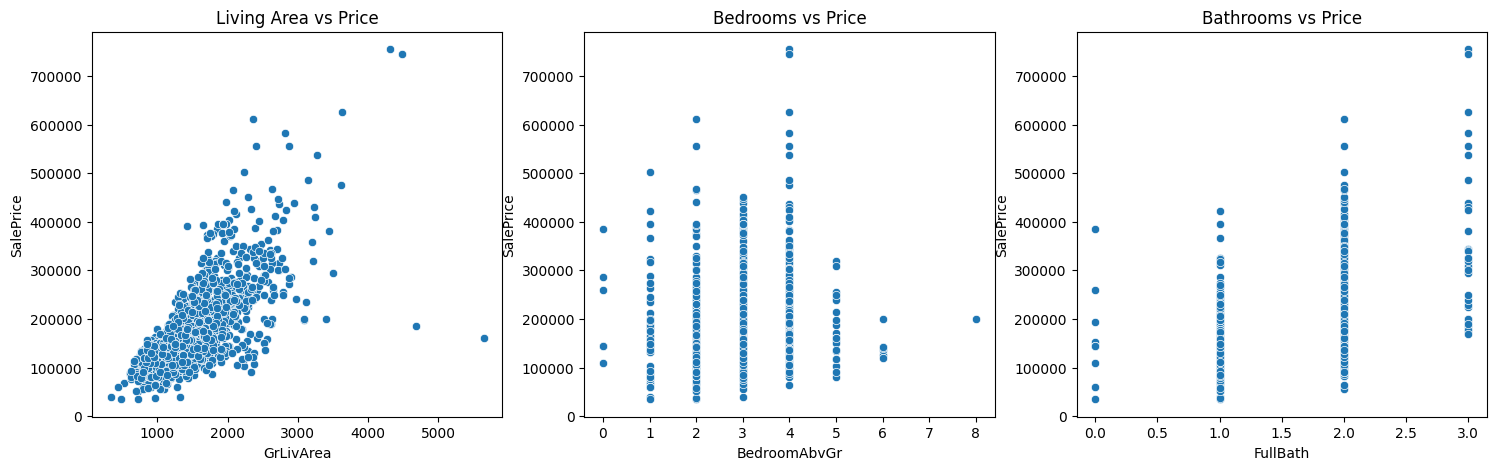

In [36]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, ax=axes[0])
axes[0].set_title("Living Area vs Price")

sns.scatterplot(x='BedroomAbvGr', y='SalePrice', data=df, ax=axes[1])
axes[1].set_title("Bedrooms vs Price")

sns.scatterplot(x='FullBath', y='SalePrice', data=df, ax=axes[2])
axes[2].set_title("Bathrooms vs Price")

plt.show()

In [37]:
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [39]:
y_pred = model.predict(X_test)

In [40]:
print("R² Score :", round(r2_score(y_test, y_pred),4))
print("MAE       :", round(mean_absolute_error(y_test, y_pred),2))
print("RMSE      :", round(np.sqrt(mean_squared_error(y_test, y_pred)),2))

R² Score : 0.6341
MAE       : 35788.06
RMSE      : 52975.72


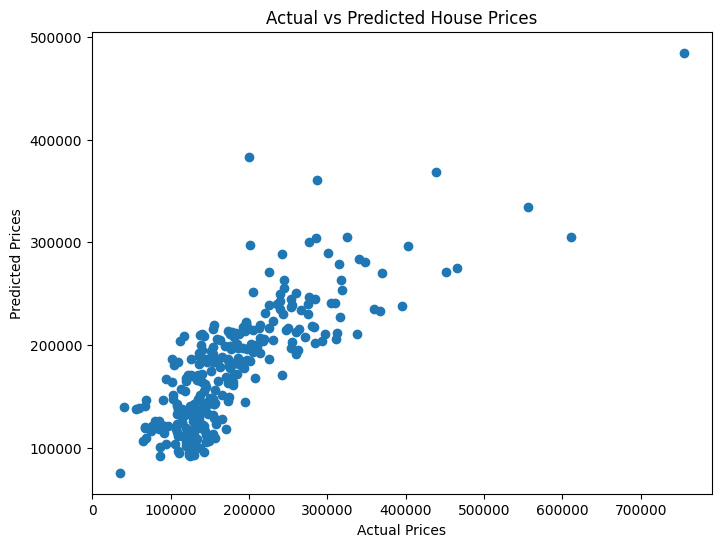

In [41]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

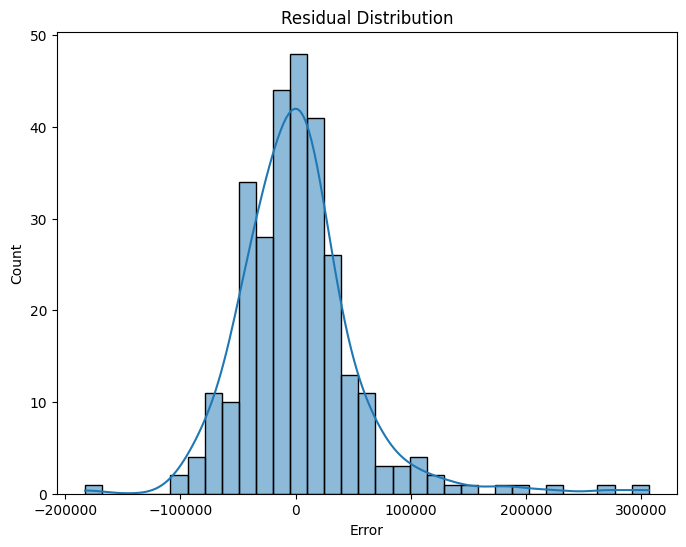

In [42]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Error")

plt.show()

In [43]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

display(coefficients)

,Feature,Coefficient
0,GrLivArea,104.026307
1,BedroomAbvGr,-26655.165357
2,FullBath,30014.324109


In [44]:
import pickle
import numpy as np
import pandas as pd # Import pandas for DataFrame functionality

# Load the saved model
try:
    with open('house_price_model.pkl', 'rb') as file:
        loaded_model = pickle.load(file)
except FileNotFoundError:
    print("Error: 'house_price_model.pkl' not found. Please ensure the model was saved.")
    loaded_model = None # Set to None to prevent further errors if model not found

if loaded_model is not None:
    # Get input from the user
    user_input_str = input("Enter GrLivArea, BedroomAbvGr, FullBath separated by commas (e.g., 1800, 4, 3): ")

    # Process the input
    try:
        user_input_list = [float(x.strip()) for x in user_input_str.split(',')]
        if len(user_input_list) == 3:
            # Create a DataFrame with feature names to match the training data
            feature_names = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
            user_new_input_df = pd.DataFrame([user_input_list], columns=feature_names)

            user_predicted_price = loaded_model.predict(user_new_input_df)
            print(f"\nPredicted house price for your input {user_input_list}: ${user_predicted_price[0]:,.2f}")
        else:
            print("Invalid input. Please enter exactly three numbers.")
    except ValueError:
        print("Invalid input. Please ensure all values are numeric.")

Error: 'house_price_model.pkl' not found. Please ensure the model was saved.
